In [9]:
import pandas as pd

In [10]:
import numpy as np

In [11]:
import matplotlib.pyplot as plt

In [12]:
pd.set_option("display.max_columns",None)
pd.set_option("display.width",200)

In [25]:
import os
print("CWD =", os.getcwd())


CWD = c:\Users\LORD ALOK\Documents\myprojects\AI-Powered-Sustainable-Packaging-Recommendation-System\EcopackAI\ml\notebooks


In [26]:
import glob
glob.glob("**/materials_raw.csv", recursive=True)


[]

In [27]:
materials_raw = pd.read_csv("../../data/raw_datasets/materials/materials_raw.csv")
products_raw  = pd.read_csv("../../data/raw_datasets/products/products_raw.csv")

materials_clean = pd.read_csv("../../data/processed/materials_db.csv")
products_clean  = pd.read_csv("../../data/processed/products.csv")

print("Loaded datasets successfully")


Loaded datasets successfully


In [28]:
materials_raw.head()


,Material ID,Packaging Type,Material Type,Suitable Product Categories,Recommended Packaging Use Cases,Supplier Region,Recyclability (%),Recyclability Category,Recycled Content (%),Reusability (%),Biodegradation Time (days),End-of-Life Disposal (%),Carbon Footprint (kg CO2/unit),CO2 Emission per kg (estimated),Waste Reduction Impact (%),Sustainability Target Progress (%),Load Handling Score,Moisture Resistance Score,Thermal Resistance Score,Cost per Unit (USD),Annual Usage (units),Total Material Weight (tons),Supplier Sustainability Compliance (%)
0,MAT_0001,Cardboard Boxes,Cardboard,"E-commerce, Food & Beverage, Consumer Goods, A...",Last-mile delivery and primary e-commerce pack...,EMEA,98,High,79.0,49.0,188.0,5.0,0.78,0.54,61.0,88.0,6.0,5.0,4.0,2.24,101260.0,790.0,85.0
1,MAT_0002,Protective Fillers (Paper/Biodegradable),Paper/Bio-Based,"Fragile Items, Cosmetics, Pharmaceuticals, Int...",Void-fill and cushioning for fragile products,APAC,100,High,93.0,31.0,65.0,2.0,0.52,0.32,68.0,98.0,3.0,3.0,3.0,1.82,73961.0,545.0,88.0
2,MAT_0003,Steel Racks & Containers,Steel,"Heavy Industrial Components, High-Security Goods","Secure, high-load international shipping and l...",AMERICAS,87,High,78.0,100.0,180208.0,8.0,3.67,3.25,85.0,79.0,8.0,9.0,9.0,25.00,14649.0,4979.0,88.0
3,MAT_0004,Protective Fillers (Paper/Biodegradable),Paper/Bio-Based,"Fragile Items, Cosmetics, Pharmaceuticals, Int...",Void-fill and cushioning for fragile products,ROW,100,High,89.0,31.0,65.0,3.0,0.48,0.31,69.0,87.0,1.0,1.0,4.0,2.43,75036.0,656.0,81.0
4,MAT_0005,Protective Fillers (Paper/Biodegradable),Paper/Bio-Based,"Fragile Items, Cosmetics, Pharmaceuticals, Int...",Void-fill and cushioning for fragile products,LATAM,100,High,92.0,28.0,122.0,3.0,0.41,0.31,61.0,89.0,3.0,2.0,3.0,1.69,69209.0,549.0,81.0


In [29]:
products_raw.head()


,product_id,product_name,category,product_weight_kg,fragility_index,shipping_type
0,1,Chocolate Box,Food,0.5,2,Air
1,2,Smartphone,Electronics,0.3,5,Air
2,3,Perfume Bottle,Cosmetics,0.2,4,Road
3,4,Medicine Pack,Pharmacy,0.1,3,Air
4,5,Snack Pack,Food,0.7,2,Road


In [30]:
print("Materials shape:", materials_raw.shape)
print("Products shape:", products_raw.shape)

print("\nMaterials columns:\n", materials_raw.columns)
print("\nProducts columns:\n", products_raw.columns)

print("\nMaterials dtypes:\n", materials_raw.dtypes)
print("\nProducts dtypes:\n", products_raw.dtypes)


Materials shape: (404, 23)
Products shape: (1500, 6)

Materials columns:
 Index(['Material ID', 'Packaging Type', 'Material Type', 'Suitable Product Categories', 'Recommended Packaging Use Cases', 'Supplier Region', 'Recyclability (%)', 'Recyclability Category',
       'Recycled Content (%)', 'Reusability (%)', 'Biodegradation Time (days)', 'End-of-Life Disposal (%)', 'Carbon Footprint (kg CO2/unit)', 'CO2 Emission per kg (estimated)',
       'Waste Reduction Impact (%)', 'Sustainability Target Progress (%)', 'Load Handling Score', 'Moisture Resistance Score', 'Thermal Resistance Score', 'Cost per Unit (USD)',
       'Annual Usage (units)', 'Total Material Weight (tons)', 'Supplier Sustainability Compliance (%)'],
      dtype='object')

Products columns:
 Index(['product_id', 'product_name', 'category', 'product_weight_kg', 'fragility_index', 'shipping_type'], dtype='object')

Materials dtypes:
 Material ID                                object
Packaging Type                           

In [31]:
materials_raw.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Material ID,404,404,MAT_0001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Packaging Type,404,6,Cardboard Boxes,139,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Material Type,404,4,Plastic,199,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Suitable Product Categories,404,6,"E-commerce, Food & Beverage, Consumer Goods, A...",139,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Recommended Packaging Use Cases,404,6,Last-mile delivery and primary e-commerce pack...,139,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Supplier Region,404,6,AMERICAS,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Recyclability (%),404.0,NaN,NaN,NaN,91.613861,8.584966,55.0,87.0,94.0,99.0,100.0
Recyclability Category,404,2,High,205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Recycled Content (%),403.0,NaN,NaN,NaN,61.833747,19.340228,21.0,47.5,68.0,79.0,94.0
Reusability (%),403.0,NaN,NaN,NaN,66.694789,28.766147,3.0,48.0,53.0,95.0,100.0


In [32]:
products_raw.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
product_id,1500.0,NaN,NaN,NaN,750.5,433.157015,1.0,375.75,750.5,1125.25,1500.0
product_name,1500,1480,"LED Monitor 32""",2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
category,1500,7,Food,343,NaN,NaN,NaN,NaN,NaN,NaN,NaN
product_weight_kg,1500.0,NaN,NaN,NaN,0.925087,1.604414,0.04,0.3,0.52,0.9,15.0
fragility_index,1500.0,NaN,NaN,NaN,2.617333,1.087361,1.0,2.0,3.0,3.0,5.0
shipping_type,1500,3,Road,928,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
mv_materials = materials_raw.isna().sum().reset_index()
mv_materials.columns = ["column", "missing_count"]
mv_materials["missing_percent"] = (mv_materials["missing_count"] / len(materials_raw)) * 100
mv_materials = mv_materials.sort_values(by="missing_count", ascending=False)
mv_materials


,column,missing_count,missing_percent
14,Waste Reduction Impact (%),1,0.247525
12,Carbon Footprint (kg CO2/unit),1,0.247525
13,CO2 Emission per kg (estimated),1,0.247525
11,End-of-Life Disposal (%),1,0.247525
10,Biodegradation Time (days),1,0.247525
9,Reusability (%),1,0.247525
8,Recycled Content (%),1,0.247525
19,Cost per Unit (USD),1,0.247525
16,Load Handling Score,1,0.247525
17,Moisture Resistance Score,1,0.247525


In [34]:
mv_materials.to_csv("../../data/processed/missing_value_table_materials.csv", index=False)
print("missing_value_table_materials.csv saved")


missing_value_table_materials.csv saved


In [35]:
mv_products = products_raw.isna().sum().reset_index()
mv_products.columns = ["column", "missing_count"]
mv_products["missing_percent"] = (mv_products["missing_count"] / len(products_raw)) * 100
mv_products = mv_products.sort_values(by="missing_count", ascending=False)
mv_products


,column,missing_count,missing_percent
0,product_id,0,0.0
1,product_name,0,0.0
2,category,0,0.0
3,product_weight_kg,0,0.0
4,fragility_index,0,0.0
5,shipping_type,0,0.0


In [36]:
mv_products.to_csv("../../data/processed/missing_value_table_products.csv", index=False)
print("missing_value_table_products.csv saved")


missing_value_table_products.csv saved


In [37]:
print("Materials duplicate rows:", materials_raw.duplicated().sum())
print("Products duplicate rows:", products_raw.duplicated().sum())


Materials duplicate rows: 0
Products duplicate rows: 0


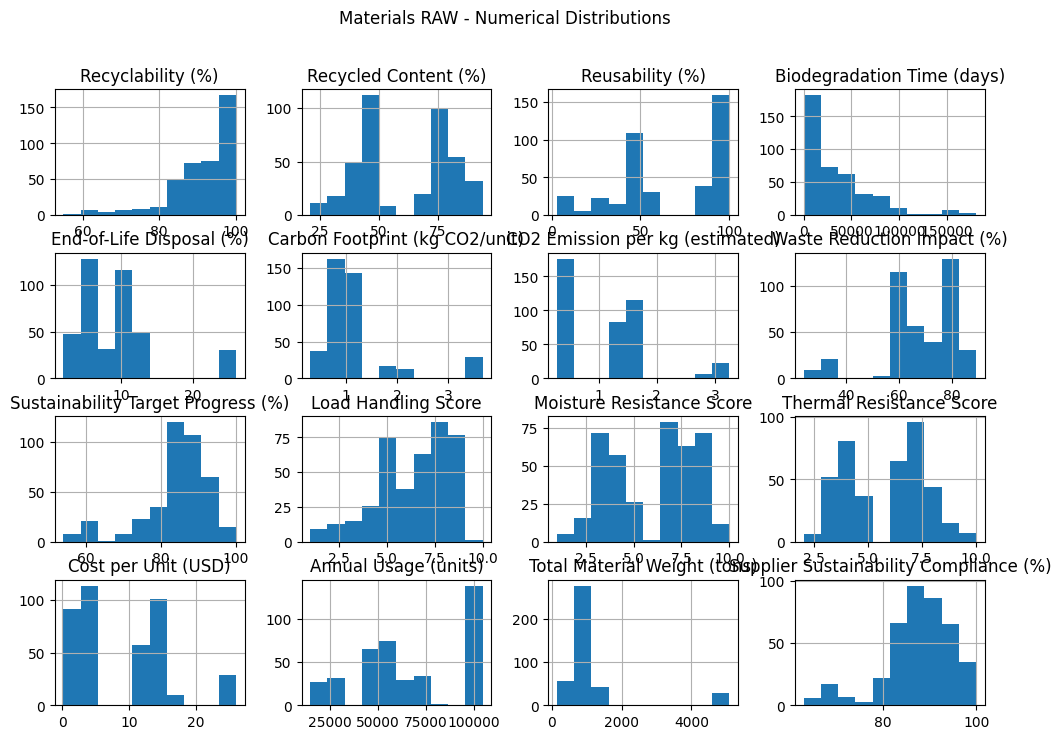

In [38]:
import matplotlib.pyplot as plt

materials_raw.select_dtypes(include=["int64","float64"]).hist(figsize=(12,8))
plt.suptitle("Materials RAW - Numerical Distributions")
plt.show()


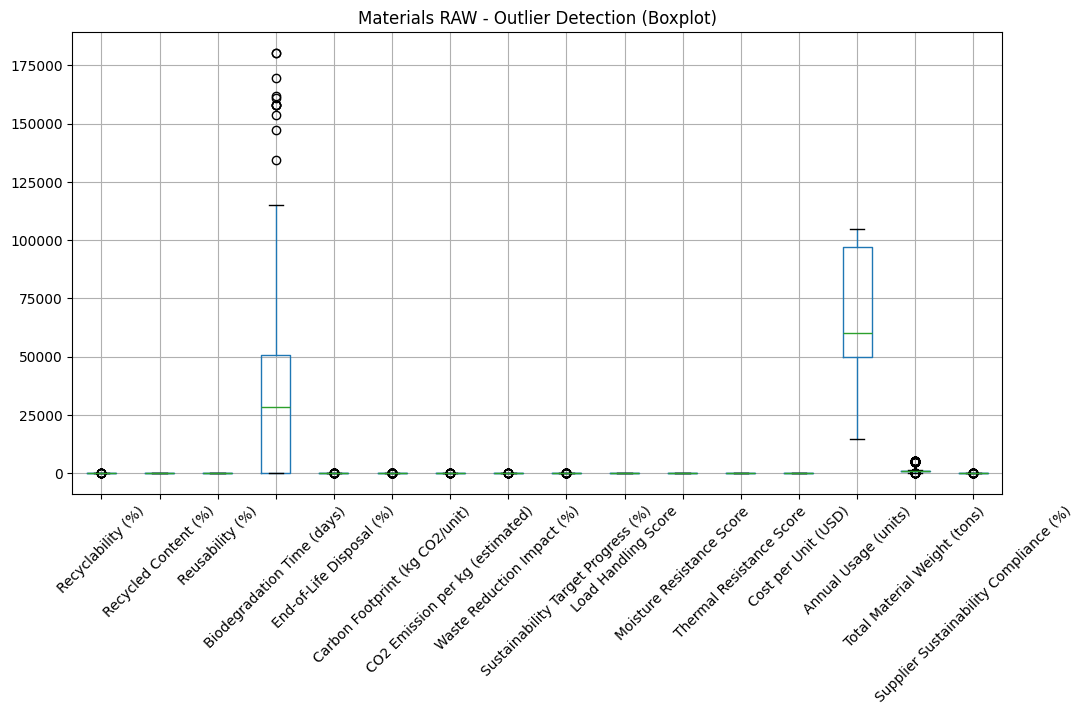

In [39]:
plt.figure(figsize=(12,6))
materials_raw.select_dtypes(include=["int64","float64"]).boxplot(rot=45)
plt.title("Materials RAW - Outlier Detection (Boxplot)")
plt.show()


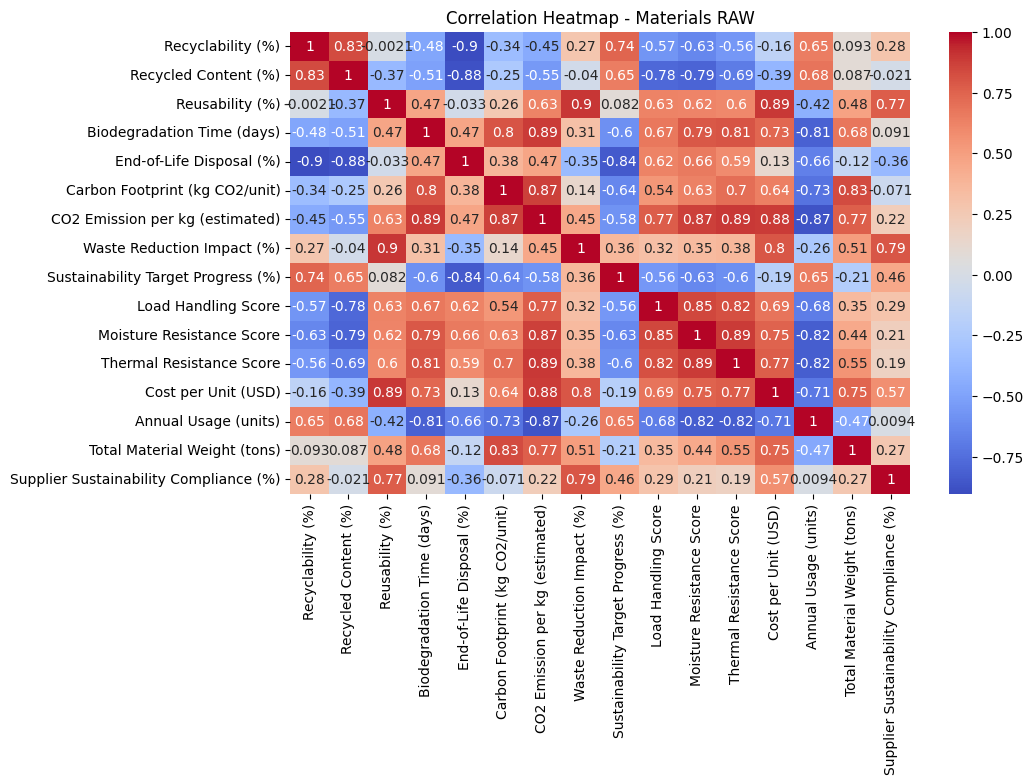

In [40]:
import seaborn as sns

corr = materials_raw.select_dtypes(include=["int64","float64"]).corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - Materials RAW")
plt.show()
